# <p style="background-color:darkslateblue; font-family:'Trebuchet MS', sans-serif; font-weight:bold; color:white; font-size:100%; text-align:center; border: 1px solid #222; border-radius:10px; padding: 10px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.3);">Predicting Traffic Accident -  EDA</p>


**Objective : The goal of this challenge is to develop a predictive model that estimates the likelihood of accidents occurring on different types of roads. Participants are expected to analyze the provided tabular dataset, perform appropriate feature engineering and preprocessing, and build a machine learning model that can accurately predict the accident_risk for each road segment. The predictions should be probabilities between 0 and 1, and model performance will be evaluated using Root Mean Squared Error (RMSE).**


# <p style="background-color:darkslateblue; font-family:'Trebuchet MS', sans-serif; font-weight:bold; color:white; font-size:80%; text-align:center; border: 1px solid #222; border-radius:10px; padding: 10px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.3);">Importing Required Libraries and Loading Dataset</p>


In [1]:
pip install "optuna-integration[xgboost]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 3.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import os 
import time 
import math
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
from category_encoders import TargetEncoder
import plotly.subplots as sp
import plotly.figure_factory as ff  

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor, plot_importance
from sklearn.model_selection import KFold, cross_val_score
from optuna.integration import XGBoostPruningCallback
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import optuna
pio.renderers.default = 'iframe_connected'
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [3]:
train = pd.read_csv('/kaggle/input/playground-series-s5e10/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s5e10/test.csv')
submission = pd.read_csv('/kaggle/input/playground-series-s5e10/sample_submission.csv')

# <p style="background-color:darkslateblue; font-family:'Trebuchet MS', sans-serif; font-weight:bold; color:white; font-size:80%; text-align:center; border: 1px solid #222; border-radius:10px; padding: 10px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.3);">Data Cleaning, Handling Missing Values </p>


In [4]:
train.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

**The dataset contains 517,754 records and 14 variables describing road and environmental conditions related to accident risk. It includes 4 integer columns (id, num_lanes, speed_limit, num_reported_accidents), 2 floating-point columns (curvature, accident_risk), 4 categorical object columns (road_type, lighting, weather, time_of_day), and 4 boolean columns (road_signs_present, public_road, holiday, school_season).**

In [6]:
train.describe().round(2)

,id,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,517754.00,517754.00,517754.00,517754.00,517754.00,517754.00
mean,258876.50,2.49,0.49,46.11,1.19,0.35
std,149462.85,1.12,0.27,15.79,0.90,0.17
min,0.00,1.00,0.00,25.00,0.00,0.00
25%,129438.25,1.00,0.26,35.00,1.00,0.23
50%,258876.50,2.00,0.51,45.00,1.00,0.34
75%,388314.75,3.00,0.71,60.00,2.00,0.46
max,517753.00,4.00,1.00,70.00,7.00,1.00


**On average, roads have approximately 2.5 lanes, a curvature of 0.49, and a speed limit of about 46 mph. The typical number of reported accidents per record is 1.19, with an average accident risk score of 0.35. The curvature ranges from 0 (flat) to 1 (highly curved). Speed limits vary between 25 mph and 70 mph. The number of lanes ranges from 1 to 4, and the number of reported accidents ranges from 0 to 7. The accident risk score spans from 0 to 1, indicating varying levels of predicted or observed risk across the dataset.**

In [7]:
print("Duplicated Rows:",train.duplicated().sum())
print("-"*30)
print("Number of Rows:",train.shape[0])
print("-"*30)
print("Number of Columns:",train.shape[1])

Duplicated Rows: 0
------------------------------
Number of Rows: 517754
------------------------------
Number of Columns: 14


In [8]:
train.isnull().sum()

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

In [9]:
print("Numeric Col Names",train.select_dtypes(include=['number']).columns)

Numeric Col Names Index(['id', 'num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents',
       'accident_risk'],
      dtype='object')


In [10]:
print("Categorical Col Names",train.select_dtypes(include=['object']).columns)

Categorical Col Names Index(['road_type', 'lighting', 'weather', 'time_of_day'], dtype='object')


In [11]:
num_col= ['num_lanes', 'curvature', 'speed_limit',
          'num_reported_accidents']
target_col = 'accident_risk'
cat_col = ['road_type', 'lighting', 'weather', 'time_of_day']
bin_col = ['road_signs_present', 'public_road', 'holiday', 'school_season']

In [12]:
for col in cat_col:
    print(f"Unique categories in '{col}' column: {train[col].unique()}")
    print("<--- --- --- --- --- --- --- --- --- --->\n")

Unique categories in 'road_type' column: ['urban' 'rural' 'highway']
<--- --- --- --- --- --- --- --- --- --->

Unique categories in 'lighting' column: ['daylight' 'dim' 'night']
<--- --- --- --- --- --- --- --- --- --->

Unique categories in 'weather' column: ['rainy' 'clear' 'foggy']
<--- --- --- --- --- --- --- --- --- --->

Unique categories in 'time_of_day' column: ['afternoon' 'evening' 'morning']
<--- --- --- --- --- --- --- --- --- --->



**The dataset contains 517,754 rows and 14 columns, with no missing or duplicated entries. All columns are complete. The categorical variables have the following unique categories: road_type includes urban, rural, and highway; lighting includes daylight, dim, and night; weather includes rainy, clear, and foggy; and time_of_day includes morning, afternoon, and evening.**

In [13]:
weather_risk = train.groupby('weather')['accident_risk'].mean().sort_values(ascending=False)
print(f"\nHighest Risk Weather: {weather_risk.index[0]} (Avg Risk: {weather_risk.iloc[0]:.3f})")
print(f"Lowest Risk Weather: {weather_risk.index[-1]} (Avg Risk: {weather_risk.iloc[-1]:.3f})")


Highest Risk Weather: foggy (Avg Risk: 0.386)
Lowest Risk Weather: clear (Avg Risk: 0.310)


In [14]:
road_risk = train.groupby('road_type')['accident_risk'].mean().sort_values(ascending=False)
print(f"\nHighest Risk Road Type: {road_risk.index[0]} (Avg Risk: {road_risk.iloc[0]:.3f})")
print(f"Lowest Risk Road Type: {road_risk.index[-1]} (Avg Risk: {road_risk.iloc[-1]:.3f})")


Highest Risk Road Type: urban (Avg Risk: 0.357)
Lowest Risk Road Type: highway (Avg Risk: 0.350)


In [15]:
time_risk = train.groupby('time_of_day')['accident_risk'].mean().sort_values(ascending=False)
print(f"\nHighest Risk Time: {time_risk.index[0]} (Avg Risk: {time_risk.iloc[0]:.3f})")
print(f"Lowest Risk Time: {time_risk.index[-1]} (Avg Risk: {time_risk.iloc[-1]:.3f})")


Highest Risk Time: evening (Avg Risk: 0.355)
Lowest Risk Time: morning (Avg Risk: 0.351)


In [16]:
print(f"\nBINARY VARIABLES IMPACT:")
for col in bin_col:
    risk_diff = train.groupby(col)['accident_risk'].mean().diff().iloc[-1]
    mean_true = train[train[col] == True]['accident_risk'].mean()
    mean_false = train[train[col] == False]['accident_risk'].mean()
    print(f"  {col}: True={mean_true:.3f}, False={mean_false:.3f}, Diff={risk_diff:.3f}")


BINARY VARIABLES IMPACT:
  road_signs_present: True=0.352, False=0.352, Diff=0.000
  public_road: True=0.358, False=0.347, Diff=0.010
  holiday: True=0.361, False=0.344, Diff=0.017
  school_season: True=0.352, False=0.353, Diff=-0.000


**Foggy weather conditions show the highest average accident risk (0.386), while clear weather has the lowest (0.310). Urban roads exhibit slightly higher risk (0.357) compared to highways (0.350). Accident risk peaks in the evening (0.355) and is lowest in the morning (0.351). Among binary factors, public roads (0.358 vs. 0.347) and holidays (0.361 vs. 0.344) are associated with higher accident risk, whereas the presence of road signs and school season status show negligible impact.**

# <p style="background-color:darkslateblue; font-family:'Trebuchet MS', sans-serif; font-weight:bold; color:white; font-size:80%; text-align:center; border: 1px solid #222; border-radius:10px; padding: 10px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.3);">Distribution of Categorical Feature </p>


In [17]:
road_type_counts = train['road_type'].value_counts().reset_index()
road_type_counts.columns = ['road_type', 'count']

fig = px.bar(
    road_type_counts,
    x='road_type',
    y='count',
    title='Road Type Distribution',
    color='road_type',  
    color_discrete_sequence=px.colors.qualitative.T10  
)

fig.update_layout(
    width=500,
    height=400,
    plot_bgcolor='black',  
    paper_bgcolor='black',  
    font_color='white'
)

fig.show()

In [18]:
lighting_counts = train['lighting'].value_counts().reset_index()
lighting_counts.columns = ['lighting', 'count']

fig = px.bar(
    lighting_counts,
    x='lighting',
    y='count',
    title='Lighting Distribution',
    color='lighting',  
    color_discrete_sequence=px.colors.qualitative.T10  
)

fig.update_layout(
    width=500,
    height=400,
    plot_bgcolor='black',  
    paper_bgcolor='black',  
    font_color='white'
)

fig.show()

In [19]:
weather_counts = train['weather'].value_counts().reset_index()
weather_counts.columns = ['weather', 'count']

fig_weather = px.bar(
    weather_counts,
    x='weather',
    y='count',
    title='Weather Condition Distribution',
    color='weather',  
    color_discrete_sequence=px.colors.qualitative.T10  
)

fig_weather.update_layout(
    width=500,
    height=400,
    plot_bgcolor='black',  
    paper_bgcolor='black',  
    font_color='white'
)

fig_weather.show()

In [20]:
time_of_day_counts = train['time_of_day'].value_counts().reset_index()
time_of_day_counts.columns = ['time_of_day', 'count']

fig_time = px.bar(
    time_of_day_counts,
    x='time_of_day',
    y='count',
    title='Time of Day Distribution',
    color='time_of_day',  
    color_discrete_sequence=px.colors.qualitative.T10  
)

fig_time.update_layout(
    width=500,
    height=400,
    plot_bgcolor='black',  
    paper_bgcolor='black',  
    font_color='white'
)

fig_time.show()

# <p style="background-color:darkslateblue; font-family:'Trebuchet MS', sans-serif; font-weight:bold; color:white; font-size:80%; text-align:center; border: 1px solid #222; border-radius:10px; padding: 10px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.3);">Distribution of Binary Values</p>


In [21]:
cols = ['road_signs_present', 'public_road', 'holiday', 'school_season']

In [22]:
df_melted = train[cols].melt(var_name="Category", value_name="Value")
counts = df_melted.groupby(["Category", "Value"]).size().reset_index(name="Count")

fig = make_subplots(
    rows=2, cols=2,
    specs=[[{'type':'domain'}, {'type':'domain'}],
           [{'type':'domain'}, {'type':'domain'}]],
    subplot_titles=cols
)

for i, col in enumerate(cols):
    row = i // 2 + 1
    col_pos = i % 2 + 1
    df_col = counts[counts['Category'] == col]
    fig.add_trace(
        go.Pie(
            labels=df_col['Value'],
            values=df_col['Count'],
            marker_colors=px.colors.qualitative.T10,
            showlegend=(i==0)  
        ),
        row=row,
        col=col_pos
    )

fig.update_layout(
    title_text='Distribution of Binary Values',
    width=600,
    height=600,
    plot_bgcolor='black',
    paper_bgcolor='black',
    font_color='white'
)

fig.show()

# <p style="background-color:darkslateblue; font-family:'Trebuchet MS', sans-serif; font-weight:bold; color:white; font-size:80%; text-align:center; border: 1px solid #222; border-radius:10px; padding: 10px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.3);">Distribution of Target Column</p>


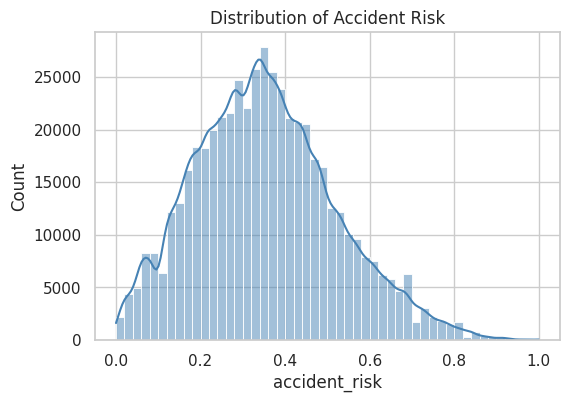

In [23]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

plt.figure(figsize=(6, 4))
sns.histplot(train[target_col], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Accident Risk')
plt.xlabel(target_col)
plt.ylabel('Count')
plt.show()

# <p style="background-color:darkslateblue; font-family:'Trebuchet MS', sans-serif; font-weight:bold; color:white; font-size:80%; text-align:center; border: 1px solid #222; border-radius:10px; padding: 10px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.3);">Distribution of Numeric Column </p>


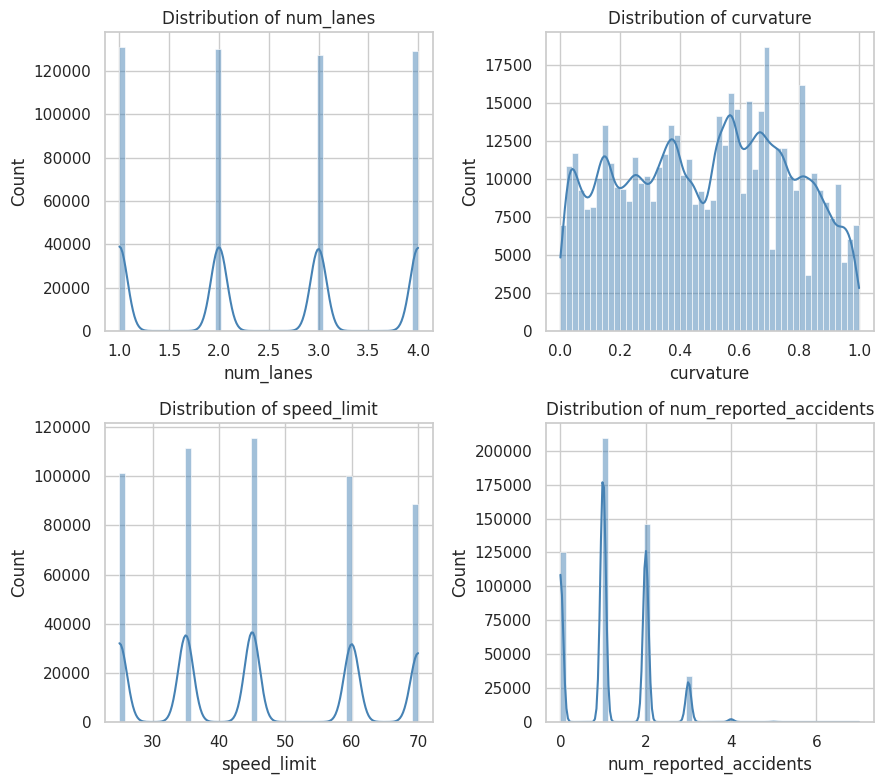

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(9, 8))  

for i, col in enumerate(num_col):
    row = i // 2
    col_pos = i % 2
    sns.histplot(train[col], bins=50, kde=True, color='steelblue', ax=axes[row, col_pos])
    axes[row, col_pos].set_title(f'Distribution of {col}')
    axes[row, col_pos].set_xlabel(col)
    axes[row, col_pos].set_ylabel('Count')

plt.tight_layout()
plt.show()

# <p style="background-color:darkslateblue; font-family:'Trebuchet MS', sans-serif; font-weight:bold; color:white; font-size:80%; text-align:center; border: 1px solid #222; border-radius:10px; padding: 10px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.3);">Accident Distribution by Road Type</p>


In [25]:
road_accidents = train.groupby('road_type')['num_reported_accidents'].sum().reset_index()

fig_road_pie = px.pie(
    road_accidents,
    names='road_type',               
    values='num_reported_accidents', 
    title='Accidents by Road Type',
    color='road_type',
    color_discrete_sequence=px.colors.qualitative.T10
)

fig_road_pie.update_layout(
    width=500,
    height=400,
    plot_bgcolor='black',  
    paper_bgcolor='black',  
    font_color='white'
)

fig_road_pie.show()

# <p style="background-color:darkslateblue; font-family:'Trebuchet MS', sans-serif; font-weight:bold; color:white; font-size:80%; text-align:center; border: 1px solid #222; border-radius:10px; padding: 10px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.3);">Accident Risk vs Boolean Categorical Features</p>

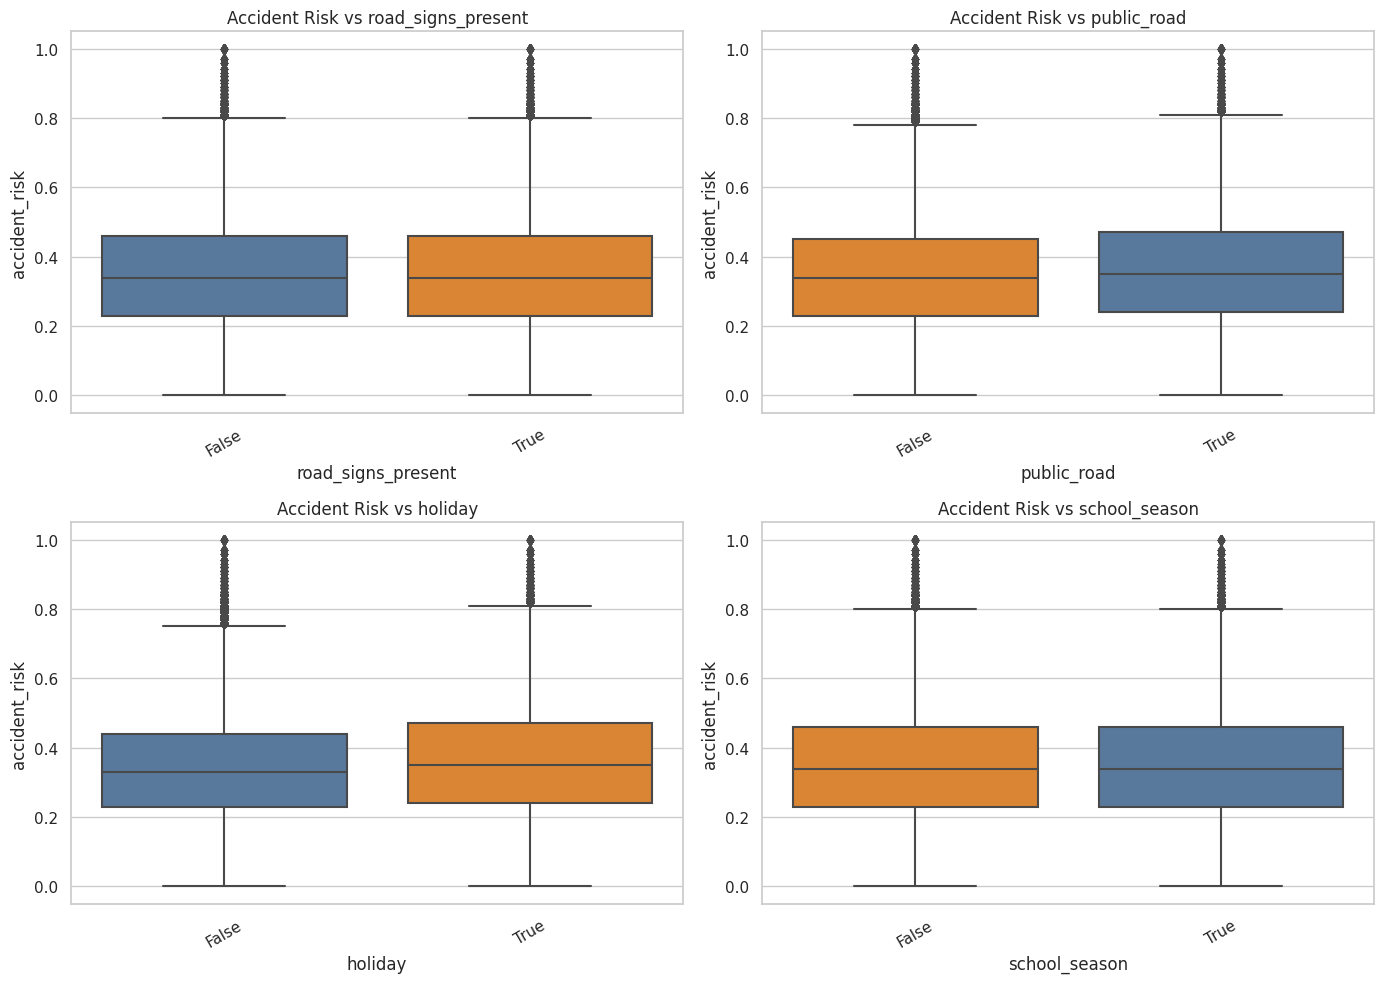

In [26]:
categorical_cols = train.select_dtypes(include=["bool"]).columns.tolist()

base_colors = px.colors.qualitative.T10

n_cols = 2
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols
plt.figure(figsize=(14, 5 * n_rows))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    
    unique_vals = train[col].unique()
    palette = {
        val: base_colors[j % len(base_colors)] 
        for j, val in enumerate(unique_vals)
    }
    
    sns.boxplot(
        x=col, 
        y="accident_risk", 
        data=train, 
        palette=palette
    )
    
    plt.xticks(rotation=30)
    plt.title(f"Accident Risk vs {col}")

plt.tight_layout()
plt.show()

# <p style="background-color:darkslateblue; font-family:'Trebuchet MS', sans-serif; font-weight:bold; color:white; font-size:80%; text-align:center; border: 1px solid #222; border-radius:10px; padding: 10px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.3);">Accident Risk vs Numerical  Features</p>

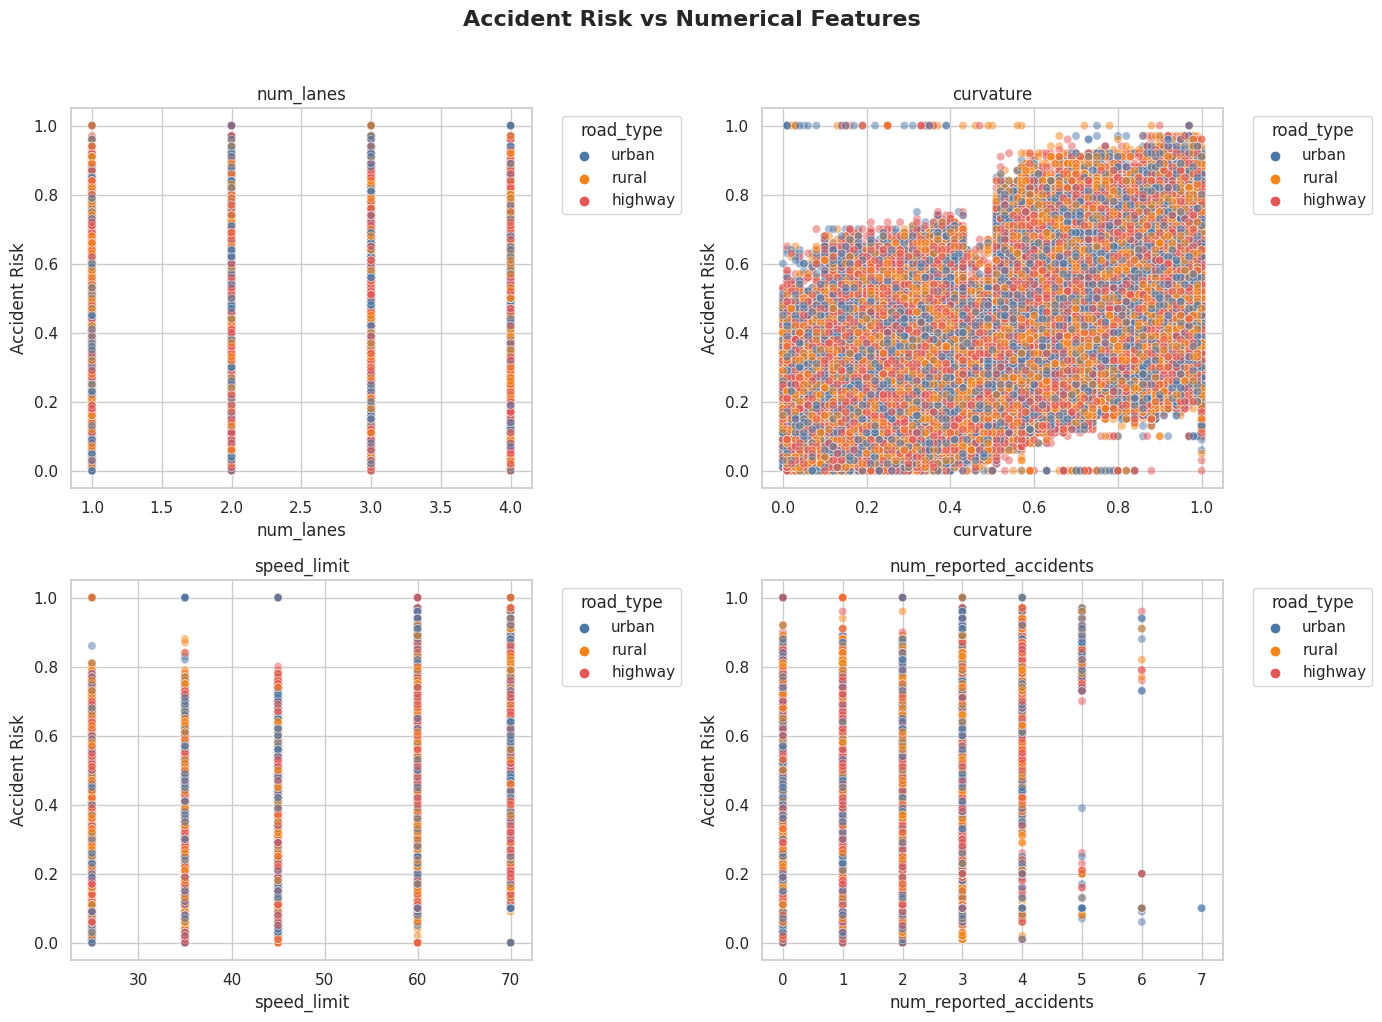

In [27]:
numerical_cols = train.select_dtypes(include=["int64", "float64"]).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ["accident_risk", "id"]]

base_colors = px.colors.qualitative.T10
n_cols = 2
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
plt.figure(figsize=(14, 5 * n_rows))
plt.suptitle("Accident Risk vs Numerical Features", fontsize=16, fontweight="bold", y=1.02)

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    unique_vals = train["road_type"].unique()
    palette = {val: base_colors[j % len(base_colors)] for j, val in enumerate(unique_vals)}
    sns.scatterplot(x=col, y="accident_risk", hue="road_type", data=train, alpha=0.5, palette=palette)
    plt.title(f"{col}")
    plt.xlabel(col)
    plt.ylabel("Accident Risk")
    plt.legend(title="road_type", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# <p style="background-color:darkslateblue; font-family:'Trebuchet MS', sans-serif; font-weight:bold; color:white; font-size:80%; text-align:center; border: 1px solid #222; border-radius:10px; padding: 10px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.3);">Accident Risk Analysis</p>

In [28]:
colors = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA']

road_type_risk = train.groupby('road_type')['accident_risk'].mean().sort_values()
weather_risk = train.groupby('weather')['accident_risk'].mean().sort_values()
time_risk = train.groupby('time_of_day')['accident_risk'].mean().sort_values()
lighting_risk = train.groupby('lighting')['accident_risk'].mean().sort_values()

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Road Type', 'Weather', 'Time of Day', 'Lighting'),
    horizontal_spacing=0.15,
    vertical_spacing=0.15
)

fig.add_trace(
    go.Bar(x=road_type_risk.values, y=road_type_risk.index, orientation='h', marker_color=colors[0]),
    row=1, col=1
)

fig.add_trace(
    go.Bar(x=weather_risk.values, y=weather_risk.index, orientation='h', marker_color=colors[1]),
    row=1, col=2
)

time_risk_sorted = time_risk.sort_values(ascending=False)
fig.add_trace(
    go.Bar(x=time_risk_sorted.values, y=time_risk_sorted.index, orientation='h', marker_color=colors[2]),
    row=2, col=1
)

fig.add_trace(
    go.Bar(x=lighting_risk.values, y=lighting_risk.index, orientation='h', marker_color=colors[3]),
    row=2, col=2
)

fig.update_layout(
    height=700,
    width=700,
    plot_bgcolor='black',
    paper_bgcolor='black',
    font_color='white',
    showlegend=False,
    title_text="Accident Risk Analysis With Category Columns",
    title_x=0.5
)

fig.show()

# <p style="background-color:darkslateblue; font-family:'Trebuchet MS', sans-serif; font-weight:bold; color:white; font-size:80%; text-align:center; border: 1px solid #222; border-radius:10px; padding: 10px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.3);">Average Accident Risk by Time of Day</p>

In [29]:
time_risk = train.groupby('time_of_day')['accident_risk'].agg(['mean', 'std', 'count']).reset_index()

time_order = ['Morning', 'Afternoon', 'Evening', 'Night']
if set(time_risk['time_of_day']).issubset(set(time_order)):
    time_risk['time_of_day'] = pd.Categorical(time_risk['time_of_day'], categories=time_order, ordered=True)
    time_risk = time_risk.sort_values('time_of_day')

fig = px.bar(
    time_risk,
    x='time_of_day',
    y='mean',
    color='time_of_day',
    color_discrete_sequence=px.colors.qualitative.T10,
    text=time_risk['mean'].round(3),
    title='Average Accident Risk by Time of Day'
)

fig.update_traces(textposition='outside')
fig.update_layout(
    width=500,
    height=400,
    plot_bgcolor='black',
    paper_bgcolor='black',
    font=dict(color='white'),
    title_font=dict(color='white'),
    xaxis=dict(title='Time of Day', showgrid=False, color='white'),
    yaxis=dict(title='Average Accident Risk', color='white'),
)

fig.show()

# <p style="background-color:darkslateblue; font-family:'Trebuchet MS', sans-serif; font-weight:bold; color:white; font-size:80%; text-align:center; border: 1px solid #222; border-radius:10px; padding: 10px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.3);">Feature Correlation Study</p>


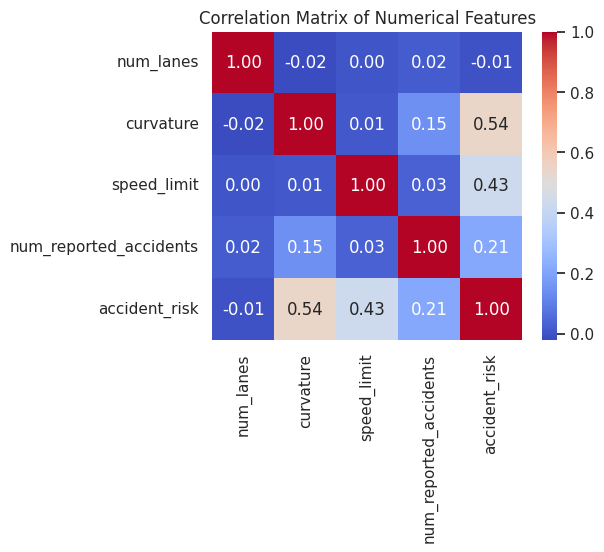

In [30]:
numerical_cols = ['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents']
corr_matrix = train[numerical_cols + ['accident_risk']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# <p style="background-color:darkslateblue; font-family:'Trebuchet MS', sans-serif; font-weight:bold; color:white; font-size:80%; text-align:center; border: 1px solid #222; border-radius:10px; padding: 10px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.3);">Feature Engineering for Road Accident Risk Prediction</p>


In [31]:
cat_cols = ['road_type', 'lighting', 'weather', 'time_of_day']
bool_cols = ['road_signs_present', 'public_road', 'holiday', 'school_season']
num_cols = ['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents']
target_col = 'accident_risk'

In [32]:
for c in bool_cols:
    if c in train.columns or test.columns:
        train[c] = train[c].astype(int)
        test[c] = test[c].astype(int)

In [33]:
def feature_engineering(df):

    df = df.copy()

    # Basic interactions
    df['speed_x_curvature'] = df['speed_limit'] * df['curvature']
    df['curv_speed'] = df['curvature'] * df['speed_limit']  
    df['curvature_squared'] = df['curvature'] ** 2
    df['speed_sq'] = df['speed_limit'] ** 2

    # Nonlinear transforms & logs (safe)
    df['accidents_log'] = np.log1p(df['num_reported_accidents'])
    df['curv_log'] = np.log1p(df['curvature'])
    df['speed_log'] = np.log1p(df['speed_limit'])
    df['inv_speed'] = 1.0 / (df['speed_limit'] + 1.0)

    # Ratios / density per lane
    df['accidents_per_lane'] = df['num_reported_accidents'] / (df['num_lanes'] + 1)
    df['curv_per_lane'] = df['curvature'] / (df['num_lanes'] + 1)
    df['speed_per_lane'] = df['speed_limit'] / (df['num_lanes'] + 1)

    # Combined risk indices
    df['danger_score'] = (df['speed_limit'] / 100.0) * (df['curvature'] ** 2)
    df['risk_density'] = df['curv_speed'] / (df['num_lanes'] + 1.0)
    df['accident_density'] = df['accidents_per_lane'] * df['speed_x_curvature']

    # Polynomial / smoother mixes
    # Use np.where to protect from negative inside sqrt though curvature and speed_limit are non-negative in domain
    df['poly_mix1'] = np.sqrt(np.maximum(df['curvature'] * df['speed_limit'], 0))
    df['poly_mix2'] = (df['num_reported_accidents'] ** 0.3) * df['speed_limit']

    # Statistical combos
    df['risk_index'] = (df['curv_speed'] * df['accidents_per_lane']) / (df['speed_limit'] + 1.0)
    df['stability_score'] = (df['num_lanes'] / (1.0 + df['curvature'])) * df['speed_limit']

    # Binary derived flags
    df['tight_lane'] = (df['num_lanes'] <= 2).astype(int)
    df['sharp_curve'] = (df['curvature'] > 0.6).astype(int)
    df['high_speed_zone'] = (df['speed_limit'] > 80).astype(int)
    df['critical_zone'] = ((df['sharp_curve'] == 1) & (df['high_speed_zone'] == 1)).astype(int)

    # Clean up infinite / extremely large values (if any)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    return df


In [34]:
train = feature_engineering(train)
test = feature_engineering(test)

# <p style="background-color:darkslateblue; font-family:'Trebuchet MS', sans-serif; font-weight:bold; color:white; font-size:80%; text-align:center; border: 1px solid #222; border-radius:10px; padding: 10px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.3);">Splitting Dataset into Training and Testing Sets</p>


In [35]:
train.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,...,risk_density,accident_density,poly_mix1,poly_mix2,risk_index,stability_score,tight_lane,sharp_curve,high_speed_zone,critical_zone
0,0,urban,2,0.06,35,daylight,rainy,0,1,afternoon,...,0.70,0.70,1.449138,35.000000,0.019444,66.037736,1,0,0,0
1,1,urban,4,0.99,35,daylight,clear,1,0,evening,...,6.93,0.00,5.886425,0.000000,0.000000,70.351759,0,1,0,0
2,2,rural,4,0.63,70,dim,clear,0,1,morning,...,8.82,17.64,6.640783,86.180109,0.248451,171.779141,0,1,0,0
3,3,highway,4,0.07,35,dim,rainy,1,1,morning,...,0.49,0.49,1.565248,35.000000,0.013611,130.841121,0,0,0,0
4,4,rural,1,0.58,60,daylight,foggy,0,0,evening,...,17.40,17.40,5.899152,60.000000,0.285246,37.974684,1,0,0,0


In [36]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 36 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  int64  
 8   public_road             517754 non-null  int64  
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  int64  
 11  school_season           517754 non-null  int64  
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
 14  speed_x_curvature   

In [37]:
X = train.drop(columns=['id', 'accident_risk'])
y = train['accident_risk']
X_test = test.drop(columns=['id'])

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# <p style="background-color:darkslateblue; font-family:'Trebuchet MS', sans-serif; font-weight:bold; color:white; font-size:80%; text-align:center; border: 1px solid #222; border-radius:10px; padding: 10px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.3);">Training Machine Learning Models</p>


In [38]:
def objective(trial, X_train_raw, y_train, cat_cols):
    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'tree_method': 'gpu_hist',
        'predictor': 'gpu_predictor',
        'verbosity': 0,
        'n_estimators': trial.suggest_int('n_estimators', 1000, 4000),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 5e-2),
        'subsample': trial.suggest_uniform('subsample', 0.7, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 0.3),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.7, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 8),
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-5, 10),
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-5, 10),
    }

    # Single validation split to avoid repeated step reporting
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_raw, y_train, test_size=0.2, random_state=42
    )

    # Target encoding for categorical features
    te = TargetEncoder(cols=cat_cols, smoothing=10.0)
    X_tr[cat_cols] = te.fit_transform(X_tr[cat_cols], y_tr)
    X_val[cat_cols] = te.transform(X_val[cat_cols])

    model = XGBRegressor(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        early_stopping_rounds=50,
        verbose=False,
        callbacks=[XGBoostPruningCallback(trial, "validation_0-rmse")]
    )

    y_pred = model.predict(X_val)
    cv_rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    print(f"Trial {trial.number} | CV RMSE: {cv_rmse:.6f} | Params: {trial.params}")
    return cv_rmse

In [39]:
#study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5, interval_steps=1))
#study.optimize(lambda trial: objective(trial, X_train, y_train, cat_cols), n_trials=100)

In [40]:
#print("Best RMSE:", study.best_value)
#print("Best hyperparameters:", study.best_params)

# <p style="background-color:darkslateblue; font-family:'Trebuchet MS', sans-serif; font-weight:bold; color:white; font-size:80%; text-align:center; border: 1px solid #222; border-radius:10px; padding: 10px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.3);">Cross-Validation and Performance Evaluation</p>

In [41]:
best_params = {
    'n_estimators': 2529,
    'max_depth': 11,
    'learning_rate': 0.04411481270144032,
    'subsample': 0.9327095844859239,
    'gamma': 0.02054596944973483,
    'colsample_bytree': 0.8858667578016076,
    'min_child_weight': 4,
    'reg_alpha': 3.9416720899763574e-05,
    'reg_lambda': 0.04064930109333212,
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'tree_method': 'gpu_hist',
    'predictor': 'gpu_predictor',
    'verbosity': 0
}

In [42]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
test_preds = np.zeros(len(X_test))
rmse_list = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Target encoding
    te = TargetEncoder(cols=cat_cols, smoothing=10.0)
    X_tr[cat_cols] = te.fit_transform(X_tr[cat_cols], y_tr).astype(float)
    X_val[cat_cols] = te.transform(X_val[cat_cols]).astype(float)
    
    # Model training
    model = XGBRegressor(**best_params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], early_stopping_rounds=50, verbose=False)
    
    # Validation prediction and RMSE
    y_pred_val = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
    rmse_list.append(rmse)
    
    # Test prediction
    X_test_encoded = X_test.copy()
    X_test_encoded[cat_cols] = te.transform(X_test_encoded[cat_cols]).astype(float)
    test_preds += model.predict(X_test_encoded) / kf.n_splits
    
    print(f"Fold {fold+1} RMSE: {rmse:.6f}")

print(f"Mean CV RMSE: {np.mean(rmse_list):.6f}")

/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:889: UserWarning:

`early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.



Fold 1 RMSE: 0.055935


/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:889: UserWarning:

`early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.



Fold 2 RMSE: 0.056481


/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:889: UserWarning:

`early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.



...

Fold 8 RMSE: 0.055842


/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:889: UserWarning:

`early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.



Fold 9 RMSE: 0.055667


/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:889: UserWarning:

`early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.



Fold 10 RMSE: 0.056087
Mean CV RMSE: 0.056037


<Figure size 1200x800 with 0 Axes>

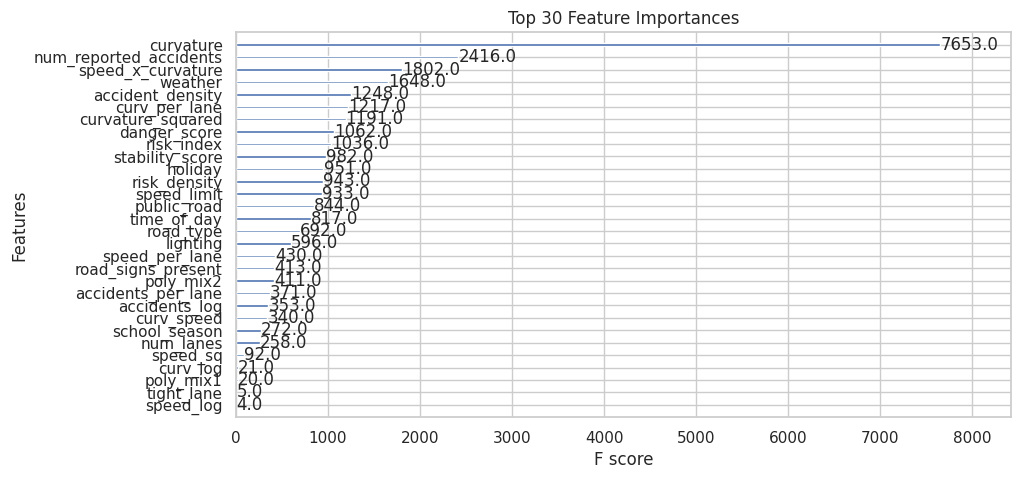

In [43]:
plt.figure(figsize=(12, 8))
plot_importance(model, max_num_features=30, importance_type='weight')
plt.title("Top 30 Feature Importances")
plt.show()

# <p style="background-color:darkslateblue; font-family:'Trebuchet MS', sans-serif; font-weight:bold; color:white; font-size:80%; text-align:center; border: 1px solid #222; border-radius:10px; padding: 10px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.3);">Generating Predictions and Preparing Submission</p>


In [44]:
test.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,...,risk_density,accident_density,poly_mix1,poly_mix2,risk_index,stability_score,tight_lane,sharp_curve,high_speed_zone,critical_zone
0,517754,highway,2,0.34,45,night,clear,1,1,afternoon,...,5.100000,5.100000,3.911521,45.000000,0.110870,67.164179,1,0,0,0
1,517755,urban,3,0.04,45,dim,foggy,1,0,afternoon,...,0.450000,0.000000,1.341641,0.000000,0.000000,129.807692,0,0,0,0
2,517756,urban,2,0.59,35,dim,clear,1,0,afternoon,...,6.883333,6.883333,4.544227,35.000000,0.191204,44.025157,1,0,0,0
3,517757,rural,4,0.95,35,daylight,rainy,0,0,afternoon,...,6.650000,13.300000,5.766281,43.090054,0.369444,71.794872,0,1,0,0
4,517758,highway,2,0.86,35,daylight,clear,1,0,evening,...,10.033333,30.100000,5.486347,48.663621,0.836111,37.634409,1,1,0,0


In [45]:
submission['accident_risk'] = test_preds

In [46]:
submission.to_csv("submission.csv", index=False)
print("✅ submission.csv saved!")

✅ submission.csv saved!


In [47]:
submission.head()

,id,accident_risk
0,517754,0.296474
1,517755,0.121295
2,517756,0.180436
3,517757,0.314430
4,517758,0.404352


In [48]:
print("\n📊 Prediction Summary:")
print(submission["accident_risk"].describe().round(2))


📊 Prediction Summary:
count    172585.00
mean          0.35
std           0.16
min           0.02
25%           0.24
50%           0.34
75%           0.45
max           0.86
Name: accident_risk, dtype: float64


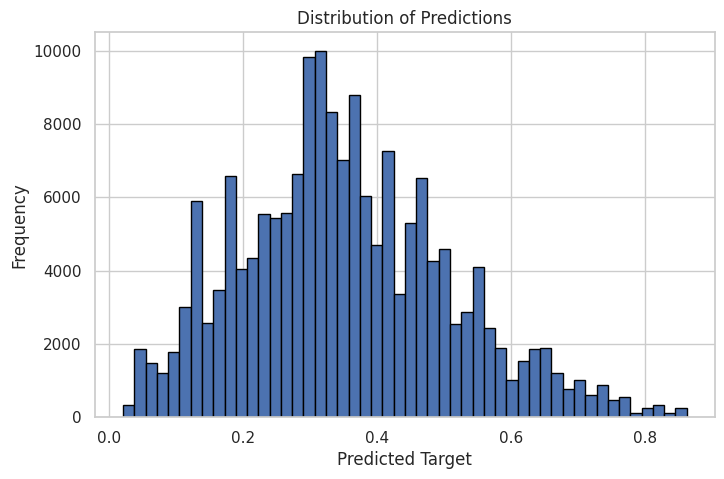

In [49]:
plt.figure(figsize=(8,5))
plt.hist(submission["accident_risk"], bins=50, edgecolor="black")
plt.title("Distribution of Predictions")
plt.xlabel("Predicted Target")
plt.ylabel("Frequency")
plt.show()